In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
customers = pd.read_excel("customers.xlsx")

# Customer Data

In [4]:
customers

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4
...,...,...,...,...,...,...
95,96,Emily Gonzalez,emily.gonzalez@example.com,Female,38,10
96,97,Emily Rodriguez,emily.rodriguez@example.com,Female,51,3
97,98,Chris Lopez,chris.lopez@example.com,Female,55,10
98,99,Laura Hernandez,laura.hernandez@example.com,Male,41,5


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    100 non-null    int64 
 1   CustomerName  100 non-null    object
 2   Email         100 non-null    object
 3   Gender        100 non-null    object
 4   Age           100 non-null    int64 
 5   GeographyID   100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [10]:
customers.isna().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
dtype: int64

In [13]:
customers.shape

(100, 6)

In [14]:
customers.duplicated().sum()

np.int64(0)

In [16]:
customers.isna().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
dtype: int64

In [17]:
customers.Gender.value_counts()

Gender
Female    54
Male      46
Name: count, dtype: int64

In [18]:
customers.Age.min(), customers.Age.max() , customers.Age.mean()

(18, 69, np.float64(41.99))

(array([ 8., 14., 10., 13., 13., 10.,  8.,  6., 10.,  8.]),
 array([18. , 23.1, 28.2, 33.3, 38.4, 43.5, 48.6, 53.7, 58.8, 63.9, 69. ]),
 <BarContainer object of 10 artists>)

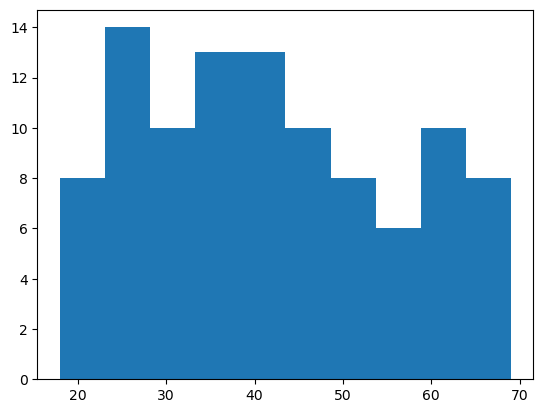

In [19]:
plt.hist(customers.Age)

In [25]:
customers.groupby('Gender')['Age'].mean()

Gender
Female    42.981481
Male      40.826087
Name: Age, dtype: float64

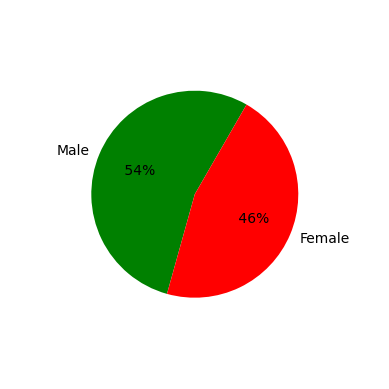

In [41]:
plt.pie(customers.Gender.value_counts(), labels= ['Male' , 'Female'] , autopct= " %1.0f%%" , startangle= 60 , radius= 0.7
        , colors= ['Green' , 'Red'] )

plt.show()

In [62]:
customers['Age_Category'] = pd.cut(customers.Age,bins=[18,30,40,50,60,70],
                                  labels=['18,30', '31-40' ,'41-50','51-60', '61-70']
                                  )
Age_Freq = customers.Age_Category.value_counts()
Age_Freq
# customers.Age_Category


Age_Category
31-40    24
18,30    22
41-50    22
51-60    16
61-70    14
Name: count, dtype: int64

(array([1., 0., 1., 0., 0., 0., 0., 0., 2., 1.]),
 array([14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.]),
 <BarContainer object of 10 artists>)

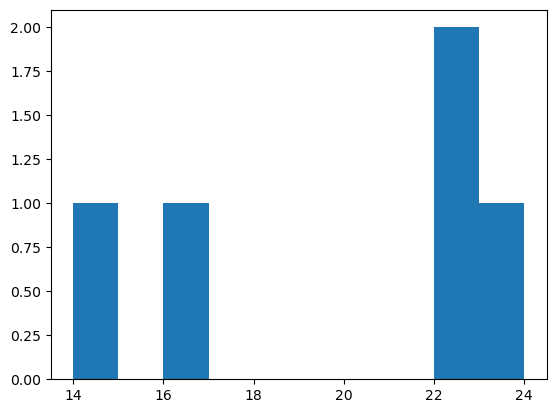

In [63]:
plt.hist(Age_Freq)

In [59]:
geograpy = pd.read_excel("geography.xlsx")
geograpy

,ID,Region,City
0,1,UK,London
1,2,Germany,Berlin
2,3,France,Paris
3,4,Spain,Madrid
4,5,Italy,Rome
5,6,Netherlands,Amsterdam
6,7,Belgium,Brussels
7,8,Sweden,Stockholm
8,9,Switzerland,Zurich
9,10,Austria,Vienna


In [61]:
customer_updated = pd.merge(customers, geograpy, how='left' , left_on='GeographyID' ,right_on='ID',).drop('ID' ,axis=1)
customer_updated.head(3)

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,41-50,Germany,Berlin
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4,31-40,Spain,Madrid
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6,"18,30",Netherlands,Amsterdam


In [ ]:
products